# 02 — Flow B: Fine-tune on MetricGAN+-Enhanced Train Audio

Fine-tunes **Whisper-base** + **Wav2Vec2-base-960h** on the MetricGAN+-enhanced version of the VoiceBank-DEMAND train split (produced by notebook 00). Test set is **not** enhanced — notebook 03 tests on raw noisy test audio for both flows.

**Switchable:** `MODE = 'lora' | 'full'` and `MODELS = ['whisper','wav2vec2']` (subset to skip a model).

**Inputs (attach):**
- `vbd-labels-enhanced-train` — provides both `transcripts.csv` and the enhanced train WAVs.
- `vbd-finetune-code` — your `train_utils.py` + `eval_utils.py`.

**Output:** push `/kaggle/working/finetuned/enhanced/` as Kaggle dataset `vbd-finetuned-enhanced`.

In [1]:
MODE = 'full'          # match NB 01's actual run for apples-to-apples comparison
CONDITION = 'enhanced' # this notebook is Flow B — do not change
EPOCHS = 5
BSZ = 8
MODELS = ['wav2vec2']  # whisper deferred; matches NB 01 run

In [2]:
!pip install -q transformers==4.46.* peft==0.13.* accelerate datasets jiwer librosa soundfile

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 96.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.

In [3]:
import os, sys, torch
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'
assert torch.cuda.is_available(), 'Enable GPU T4 x1.'

CODE_PATH = '/kaggle/input/notebooks/tejaswagg/vbd-finetune-code'
if CODE_PATH not in sys.path:
    sys.path.insert(0, CODE_PATH)
import train_utils
print('train_utils loaded from:', train_utils.__file__)

train_utils loaded from: /kaggle/input/notebooks/tejaswagg/vbd-finetune-code/train_utils.py


In [4]:
TRANSCRIPTS_CSV = '/kaggle/input/datasets/tejaswagg/vbd-labels-enhanced-train/transcripts.csv'
ENHANCED_DIR    = '/kaggle/input/datasets/tejaswagg/vbd-labels-enhanced-train/enhanced_train'
OUT_ROOT        = f'/kaggle/working/finetuned/{CONDITION}'
os.makedirs(OUT_ROOT, exist_ok=True)

n_wavs = sum(1 for _ in os.scandir(ENHANCED_DIR) if _.name.endswith('.wav'))
print(f'enhanced WAVs available: {n_wavs}')
assert n_wavs > 10000, 'Expected ~11572 enhanced train WAVs; check that the dataset is attached.'

enhanced WAVs available: 11572


## Run training

Bit-identical to notebook 01 except `audio_source='enhanced'` makes the dataset
wrapper read pre-cached enhanced WAVs instead of `row['noisy']['array']`.

In [5]:
results = train_utils.run_training(
    condition=CONDITION,
    mode=MODE,
    transcripts_csv=TRANSCRIPTS_CSV,
    enhanced_dir=ENHANCED_DIR,
    out_root=OUT_ROOT,
    epochs=EPOCHS,
    bsz=BSZ,
    models=MODELS,
)
print('done. trained:', list(results.keys()))

README.md:   0%|          | 0.00/652 [00:00<?, ?B/s]

data/train-00000-of-00005.parquet:   0%|          | 0.00/444M [00:00<?, ?B/s]

data/train-00001-of-00005.parquet:   0%|          | 0.00/416M [00:00<?, ?B/s]

data/train-00002-of-00005.parquet:   0%|          | 0.00/431M [00:00<?, ?B/s]

data/train-00003-of-00005.parquet:   0%|          | 0.00/444M [00:00<?, ?B/s]

...

{'loss': 89.3529, 'grad_norm': 102199400.0, 'learning_rate': 8.549931600547196e-07, 'epoch': 4.915514592933948}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

{'loss': 92.4488, 'grad_norm': 100363416.0, 'learning_rate': 0.0, 'epoch': 4.99231950844854}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

{'eval_loss': 62.229759216308594, 'eval_wer': 0.10998502821605435, 'eval_runtime': 41.3264, 'eval_samples_per_second': 28.021, 'eval_steps_per_second': 1.766, 'epoch': 4.99231950844854}
{'train_runtime': 6437.6762, 'train_samples_per_second': 8.088, 'train_steps_per_second': 0.252, 'train_loss': 120.40755934495192, 'epoch': 4.99231950844854}
done. trained: ['wav2vec2']


In [6]:
from pathlib import Path
for p in sorted(Path(OUT_ROOT).rglob('*')):
    if p.is_file():
        print(f'{p.relative_to("/kaggle/working")}  ({p.stat().st_size//1024} KB)')

finetuned/enhanced/wav2vec2_base_full/checkpoint-1625/config.json  (2 KB)
finetuned/enhanced/wav2vec2_base_full/checkpoint-1625/model.safetensors  (368760 KB)
finetuned/enhanced/wav2vec2_base_full/checkpoint-1625/optimizer.pt  (704822 KB)
finetuned/enhanced/wav2vec2_base_full/checkpoint-1625/rng_state.pth  (14 KB)
finetuned/enhanced/wav2vec2_base_full/checkpoint-1625/scheduler.pt  (1 KB)
finetuned/enhanced/wav2vec2_base_full/checkpoint-1625/trainer_state.json  (12 KB)
finetuned/enhanced/wav2vec2_base_full/checkpoint-1625/training_args.bin  (5 KB)
finetuned/enhanced/wav2vec2_base_full/config.json  (2 KB)
finetuned/enhanced/wav2vec2_base_full/model.safetensors  (368760 KB)
finetuned/enhanced/wav2vec2_base_full/preprocessor_config.json  (0 KB)
finetuned/enhanced/wav2vec2_base_full/special_tokens_map.json  (0 KB)
finetuned/enhanced/wav2vec2_base_full/tokenizer_config.json  (1 KB)
finetuned/enhanced/wav2vec2_base_full/train_log.jsonl  (9 KB)
finetuned/enhanced/wav2vec2_base_full/training_ar

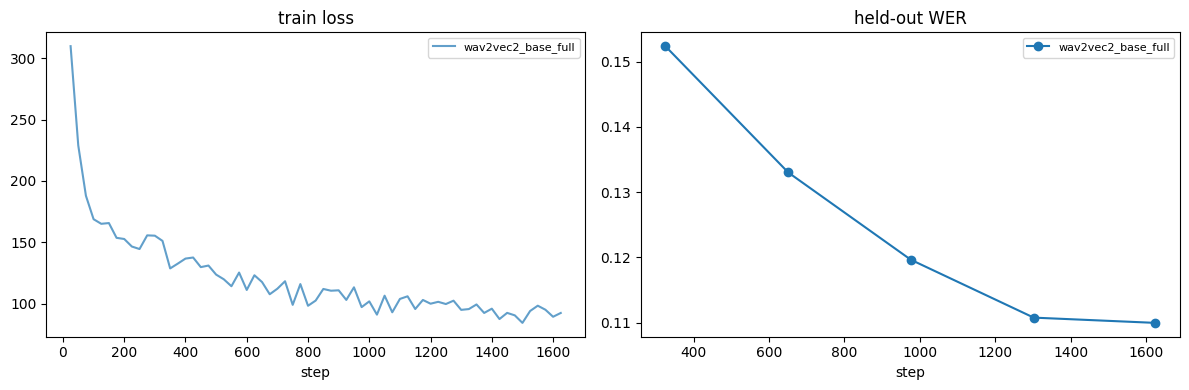

In [7]:
import json, matplotlib.pyplot as plt
from pathlib import Path
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for log in Path(OUT_ROOT).rglob('train_log.jsonl'):
    rows = [json.loads(l) for l in open(log) if l.strip()]
    loss = [(r['step'], r['loss']) for r in rows if 'loss' in r]
    wer  = [(r['step'], r['eval_wer']) for r in rows if 'eval_wer' in r]
    label = log.parent.name
    if loss: axes[0].plot(*zip(*loss), label=label, alpha=0.7)
    if wer:  axes[1].plot(*zip(*wer), marker='o', label=label)
axes[0].set_title('train loss'); axes[0].legend(fontsize=8); axes[0].set_xlabel('step')
axes[1].set_title('held-out WER'); axes[1].legend(fontsize=8); axes[1].set_xlabel('step')
plt.tight_layout(); plt.savefig(f'{OUT_ROOT}/training_curves_preview.png', dpi=150); plt.show()

## Next

1. `Save Version → Save & Run All`.
2. Output tab → **Create new dataset** named `vbd-finetuned-enhanced` from `/kaggle/working/finetuned/`.
3. Move on to notebook 03.